# Convolutional Neural Networks — Hands-on Notebook

Companion notebook for the **Convolutional Neural Networks** Deep Learning session. Everything here is built with **Keras / TensorFlow** (except the final section, see note there).

**Before you run this:** in Colab, go to `Runtime → Change runtime type → GPU (T4)`. Everything below assumes a GPU is available.

**What's inside**

1. Load and explore the **MNIST** dataset
2. Build, train, evaluate and visualize predictions of a **simple CNN** on MNIST
3. Compare it to a **VGG16 transfer-learning** model
4. Repeat the same workflow on **CIFAR-10**
5. **YOLOv8** object detection and instance segmentation on sample images of people and cars
6. Wrap-up: side-by-side comparison and key takeaways


## Setup

In [1]:
# Colab already ships TensorFlow, scikit-learn, matplotlib, seaborn and pandas.
# Uncomment if you're running this somewhere else:
# !pip install -q tensorflow scikit-learn seaborn pandas matplotlib

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# Collects test accuracy / params / train time for every experiment below,
# used for the final side-by-side comparison in the wrap-up section.
results = {}

TensorFlow: 2.20.0
Keras: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Part 1 — MNIST: a simple CNN from scratch

Mirrors the CNN pipeline from the slides: `Convolution → non-linearity → pooling → (repeat) → fully connected → softmax`.


### 1.1 Load the dataset

In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train:", x_train_full.shape, y_train_full.shape)
print("Test :", x_test.shape, y_test.shape)
print("Pixel range:", x_train_full.min(), "-", x_train_full.max())
print("Classes:", np.unique(y_train_full))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Pixel range: 0 - 255
Classes: [0 1 2 3 4 5 6 7 8 9]


### 1.2 Look at the data

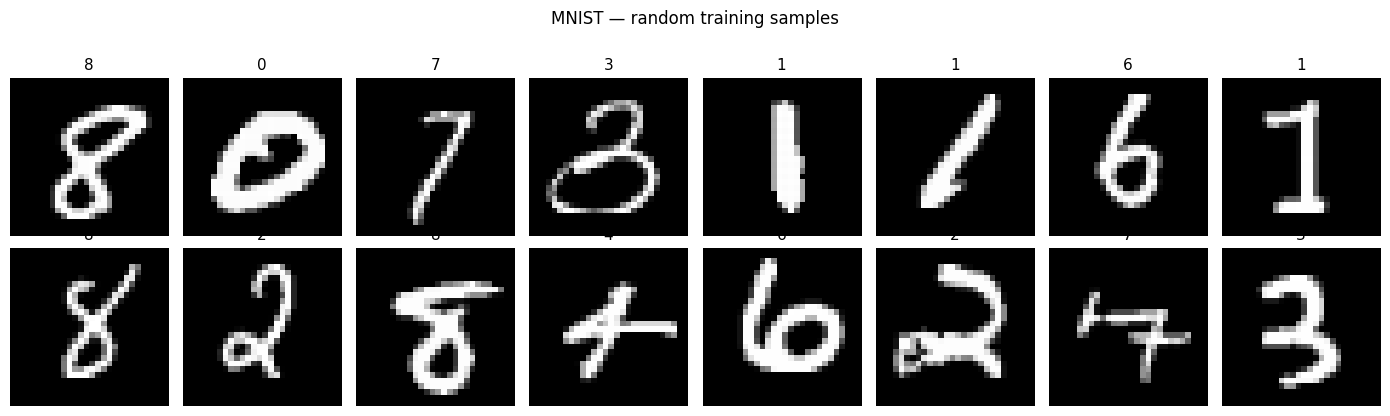

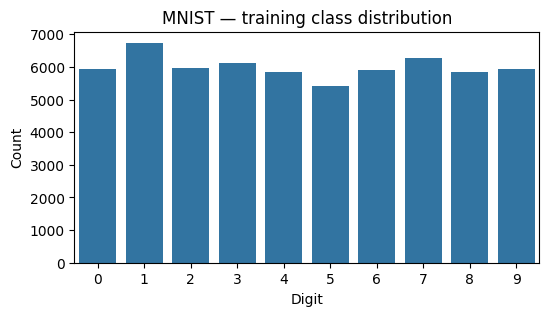

In [ ]:
class_names_mnist = [str(i) for i in range(10)]

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
sample_idx = rng.choice(len(x_train_full), size=16, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(str(y_train_full[idx]), fontsize=11)
    ax.axis("off")
fig.suptitle("MNIST — random training samples", y=1.03)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
sns.countplot(x=y_train_full)
plt.title("MNIST — training class distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

### 1.3 Preprocess

In [ ]:
def preprocess_mnist(images):
    images = images.astype("float32") / 255.0
    images = np.expand_dims(images, axis=-1)  # (N, 28, 28) -> (N, 28, 28, 1)
    return images

x_train_full_p = preprocess_mnist(x_train_full)
x_test_p = preprocess_mnist(x_test)

# Hold out a validation split from the training set
n_val = int(len(x_train_full_p) * 0.1)
x_val, y_val = x_train_full_p[:n_val], y_train_full[:n_val]
x_train, y_train = x_train_full_p[n_val:], y_train_full[n_val:]

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test_p.shape)

Train: (54000, 28, 28, 1) Val: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)


### 1.4 Build a simple CNN

In [ ]:
mnist_cnn = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # num of kernels , kernel size , padding = same => output = input shape
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        # flat to put in fully connected layer
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="simple_cnn_mnist")

mnist_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="crossentropy",
    metrics=["accuracy"])

mnist_cnn.summary()

Model: "simple_cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

### 1.5 Train

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2), # يظبط ال learning rate
]

t0 = time.time()
history = mnist_cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=True,
)
mnist_cnn_train_time = time.time() - t0
print(f"Training time: {mnist_cnn_train_time:.1f}s")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8713 - loss: 0.4215 - val_accuracy: 0.8623 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9564 - loss: 0.1512 - val_accuracy: 0.9837 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9667 - loss: 0.1141 - val_accuracy: 0.9857 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9720 - loss: 0.0965 - val_accuracy: 0.9868 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9755 - loss: 0.0839 - val_accuracy: 0.9865 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9766 - loss: 0.0774 - val_accuracy: 0.9885 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9797 - loss: 0.0679 

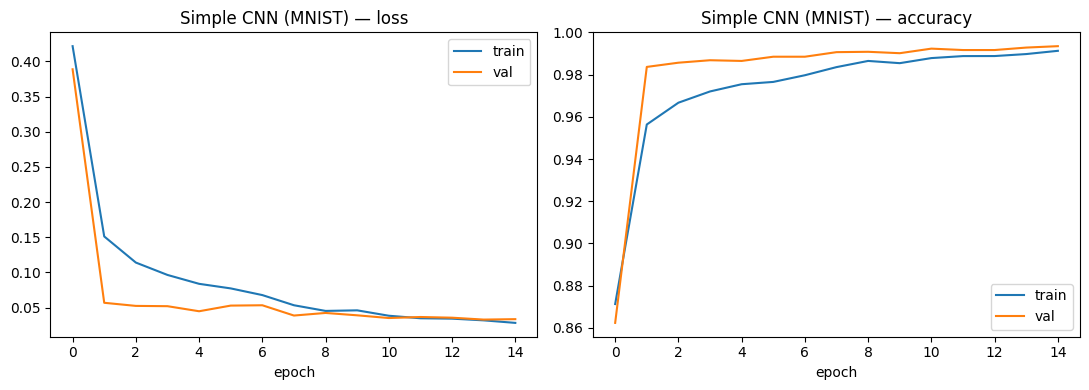

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history, "Simple CNN (MNIST)")

### 1.6 Evaluate

Test accuracy: 0.9932   Test loss: 0.0220
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



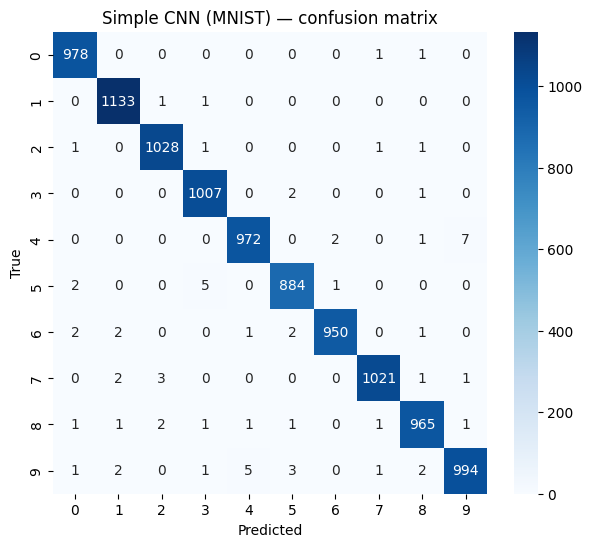

In [ ]:
test_loss, test_acc = mnist_cnn.evaluate(x_test_p, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}")

y_pred_probs = mnist_cnn.predict(x_test_p, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names_mnist))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_mnist, yticklabels=class_names_mnist)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Simple CNN (MNIST) — confusion matrix")
plt.show()

results["MNIST - Simple CNN"] = {
    "test_acc": test_acc,
    "params": mnist_cnn.count_params(),
    "train_time_s": mnist_cnn_train_time,
}

### 1.7 Visualize predictions

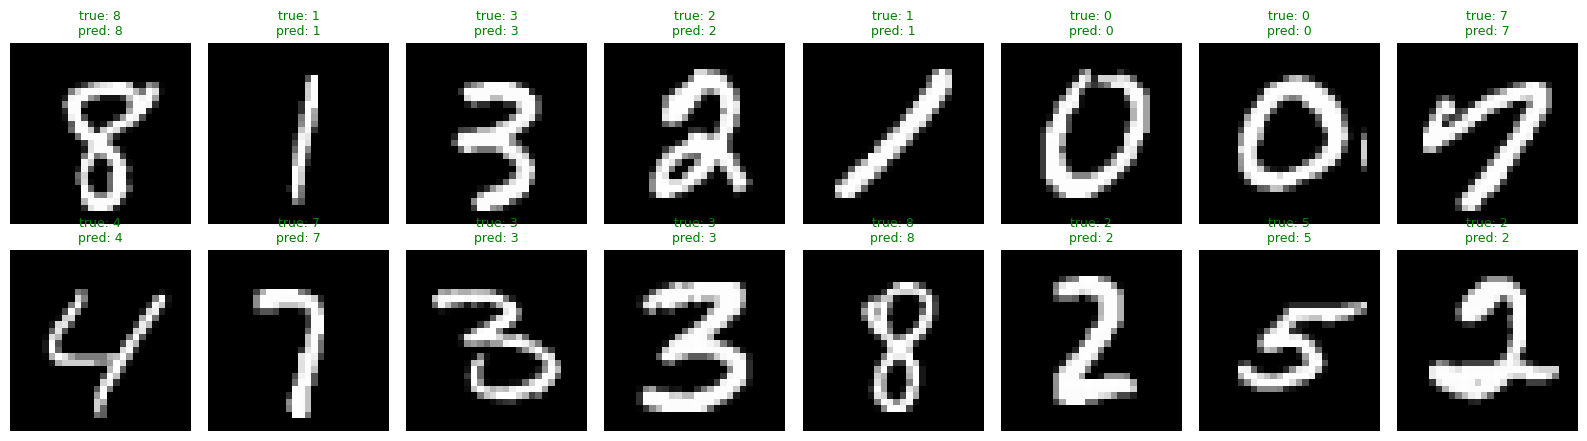

In [ ]:
def show_predictions(images, y_true, y_pred, class_names, n=16, cmap="gray"):
    idx = rng.choice(len(images), size=n, replace=False)
    cols = 8
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.2 * rows))
    for ax, i in zip(axes.flat, idx):
        img = images[i]
        if img.shape[-1] == 1:
            img = img.squeeze(-1)
        ax.imshow(img, cmap=cmap)
        correct = y_true[i] == y_pred[i]
        color = "green" if correct else "red"
        ax.set_title(f"true: {class_names[y_true[i]]}\npred: {class_names[y_pred[i]]}",
                     color=color, fontsize=9)
        ax.axis("off")
    for ax in axes.flat[len(idx):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(x_test_p, y_test, y_pred, class_names_mnist)

---
## Part 2 — Transfer learning with VGG16 on MNIST

VGG16 expects **3-channel** images of at least **32×32**. MNIST is grayscale and 28×28, so we build a small `tf.data` pipeline that upsamples and replicates channels before handing images to the pretrained network.

The convolutional base is **frozen** (ImageNet weights, not trainable) and produces the same output for a given image on every epoch — so instead of re-running it every epoch, we run it **once** to extract "bottleneck features", then train only a small classifier head on those features. This is the standard fast way to do feature-extraction-style transfer learning.


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

IMG_SIZE = 32  # smallest input VGG16 accepts

def make_vgg16_pipeline_mnist(images_uint8, batch_size=256):
    ds = tf.data.Dataset.from_tensor_slices(images_uint8)
    ds = ds.map(lambda img: tf.expand_dims(img, -1), num_parallel_calls=tf.data.AUTOTUNE)        # (28,28) -> (28,28,1)
    ds = ds.map(lambda img: tf.image.grayscale_to_rgb(img), num_parallel_calls=tf.data.AUTOTUNE)   # -> (28,28,3)
    ds = ds.map(lambda img: tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda img: preprocess_input(img), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

vgg16_base = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg")
vgg16_base.trainable = False
vgg16_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
def extract_features(images_uint8, base_model, pipeline_fn, batch_size=256):
    ds = pipeline_fn(images_uint8, batch_size=batch_size)
    return base_model.predict(ds, verbose=1)

t0 = time.time()
feat_train = extract_features(x_train_full[n_val:], vgg16_base, make_vgg16_pipeline_mnist)
feat_val = extract_features(x_train_full[:n_val], vgg16_base, make_vgg16_pipeline_mnist)
feat_test = extract_features(x_test, vgg16_base, make_vgg16_pipeline_mnist)
vgg16_mnist_feature_time = time.time() - t0
print("Feature shape:", feat_train.shape, f"(extracted in {vgg16_mnist_feature_time:.1f}s)")

211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step
Feature shape: (54000, 512) (extracted in 25.1s)


Model: "vgg16_head_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,898 (523.04 KB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 - 4s - 11ms/step - accuracy: 0.7674 - loss: 1.4432 - val_accuracy: 0.9112 - val_loss: 0.2936
Epoch 2/15
422/422 - 1s - 3ms/step - accuracy: 0.8795 - loss: 0.3802 - val_accuracy: 0.9308 - val_loss: 0.2306
Epoch 3/15
422/422 - 1s - 3ms/step - accuracy: 0.9019 - loss: 0.3087 - val_accuracy: 0.9375 - val_loss: 0.2038
Epoch 4/15
422/422 - 1s - 3ms/step - accuracy: 0.9132 - loss: 0.2710 - val_accuracy: 0.9450 - val_loss: 0.1867
Epoch 5/15
422/422 - 1s - 3ms/step - accuracy: 0.9189 - loss: 0.2537 - val_accuracy: 0.9430 - val_loss: 0.1878
Epoch 6/15
422/422 - 2s - 4ms/step - accuracy: 0.9234 - loss: 0.2388 - val_accuracy: 0.9422 - val_loss: 0.1858
Epoch 7/15
422/422 - 1s - 3ms/step - accuracy: 0.9259 - loss: 0.2295 - val_accuracy: 0.9452 - val_loss: 0.1756
Epoch 8/15
422/422 - 1s - 3ms/step - accuracy: 0.9289 - loss: 0.2189 - val_accuracy: 0.9477 - val_loss: 0.1618
Epoch 9/15
422/422 - 1s - 3ms/step - accuracy: 0.9314 - loss: 0.2128 - val_accuracy: 0.9482 - val_loss: 0.1679


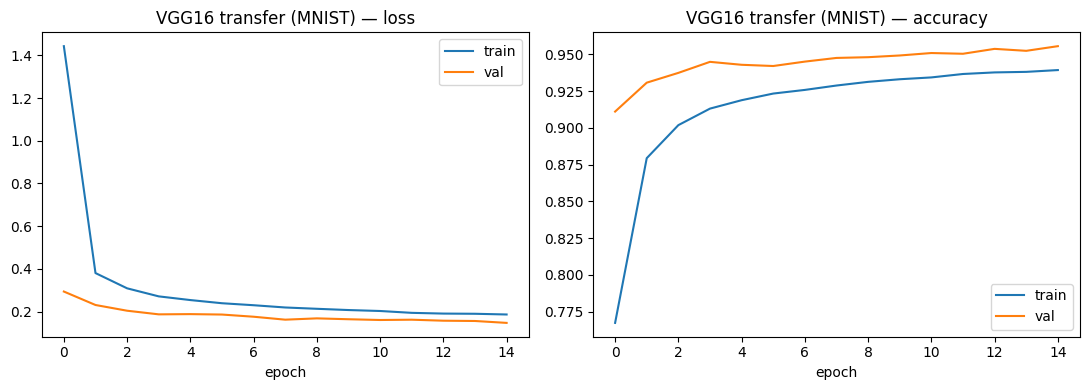

In [ ]:
def build_head(input_dim, num_classes=10, name="head"):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

mnist_vgg16_head = build_head(feat_train.shape[1], name="vgg16_head_mnist")
mnist_vgg16_head.summary()

t0 = time.time()
history_vgg16_mnist = mnist_vgg16_head.fit(
    feat_train, y_train,
    validation_data=(feat_val, y_val),
    epochs=15, batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=2,
)
mnist_vgg16_train_time = time.time() - t0 + vgg16_mnist_feature_time
plot_history(history_vgg16_mnist, "VGG16 transfer (MNIST)")

Test accuracy: 0.9563
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.93      0.96      0.94      1032
           3       0.94      0.93      0.94      1010
           4       0.95      0.97      0.96       982
           5       0.91      0.93      0.92       892
           6       0.97      0.96      0.97       958
           7       0.98      0.94      0.96      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



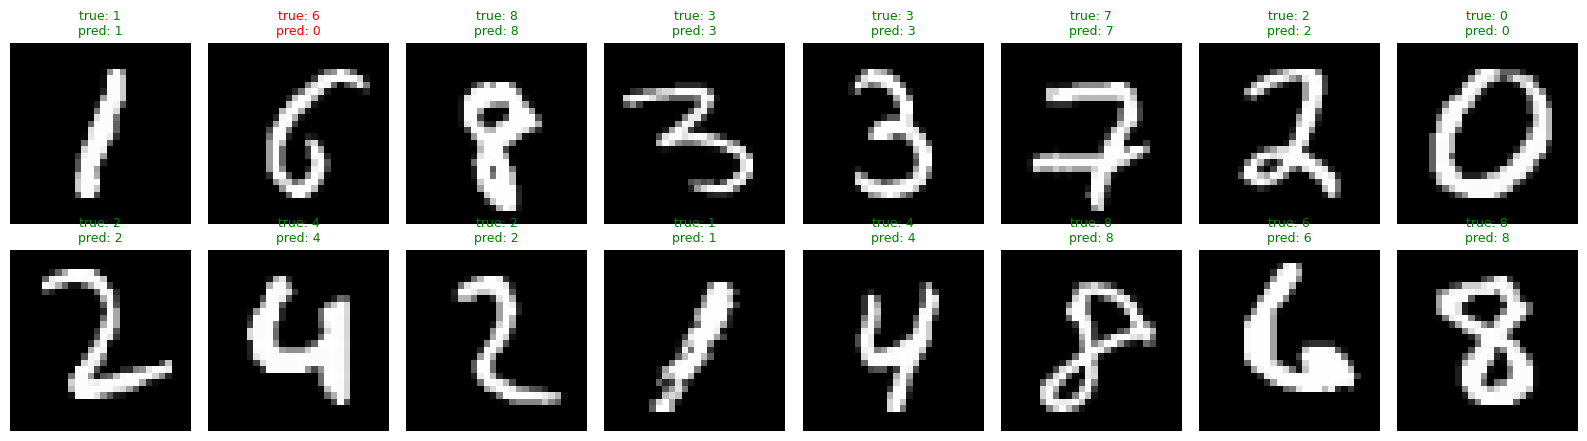

In [ ]:
test_loss, test_acc = mnist_vgg16_head.evaluate(feat_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_vgg16_mnist = np.argmax(mnist_vgg16_head.predict(feat_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred_vgg16_mnist, target_names=class_names_mnist))

show_predictions(x_test_p, y_test, y_pred_vgg16_mnist, class_names_mnist)

results["MNIST - VGG16 transfer"] = {
    "test_acc": test_acc,
    "params": mnist_vgg16_head.count_params() + vgg16_base.count_params(),
    "train_time_s": mnist_vgg16_train_time,
}

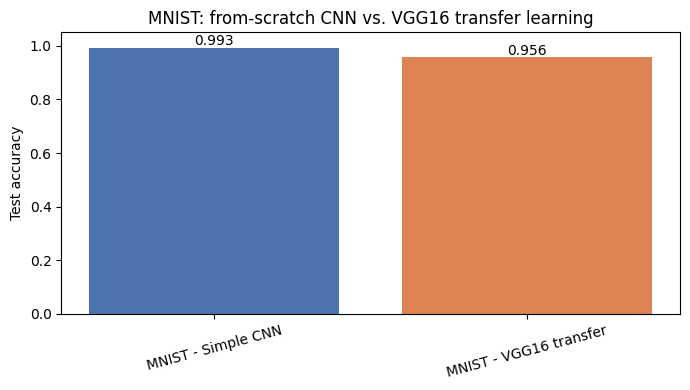

In [ ]:
def plot_comparison(keys, title):
    accs = [results[k]["test_acc"] for k in keys]
    plt.figure(figsize=(7, 4))
    bars = plt.bar(keys, accs, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(keys)])
    plt.ylim(0, 1.05)
    plt.ylabel("Test accuracy")
    plt.title(title)
    for b, a in zip(bars, accs):
        plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f"{a:.3f}", ha="center")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

plot_comparison(["MNIST - Simple CNN", "MNIST - VGG16 transfer"],
                 "MNIST: from-scratch CNN vs. VGG16 transfer learning")

**Why might the tiny from-scratch CNN match (or beat) VGG16 here?** VGG16's filters were learned on natural ImageNet photos — textures, fur, edges of real-world objects. MNIST digits are binary-ish strokes on a blank background, a very different visual domain, so the pretrained filters aren't a great match. Transfer learning helps most when the source and target domains actually look alike — which is exactly why VGG became "the default feature extractor for years" for natural-image tasks, and why we'd expect it to do better on CIFAR-10 next.

*(Optional extension: unfreeze the last VGG16 conv block — `vgg16_base.trainable = True` then re-freeze all but the last few layers — and fine-tune end-to-end with a low learning rate, e.g. `1e-5`. Left out here to keep the session's runtime short.)*


---
## Part 3 — Same workflow on CIFAR-10

CIFAR-10 is 32×32 **RGB** already — no resizing or grayscale-to-RGB conversion needed for VGG16 this time.


### 3.1 Load the dataset

In [ ]:
(x_train_full_c, y_train_full_c), (x_test_c, y_test_c) = keras.datasets.cifar10.load_data()
y_train_full_c = y_train_full_c.squeeze(-1)
y_test_c = y_test_c.squeeze(-1)

class_names_cifar = ["airplane", "automobile", "bird", "cat", "deer",
                      "dog", "frog", "horse", "ship", "truck"]

print("Train:", x_train_full_c.shape, "Test:", x_test_c.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2077s 12us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


### 3.2 Look at the data

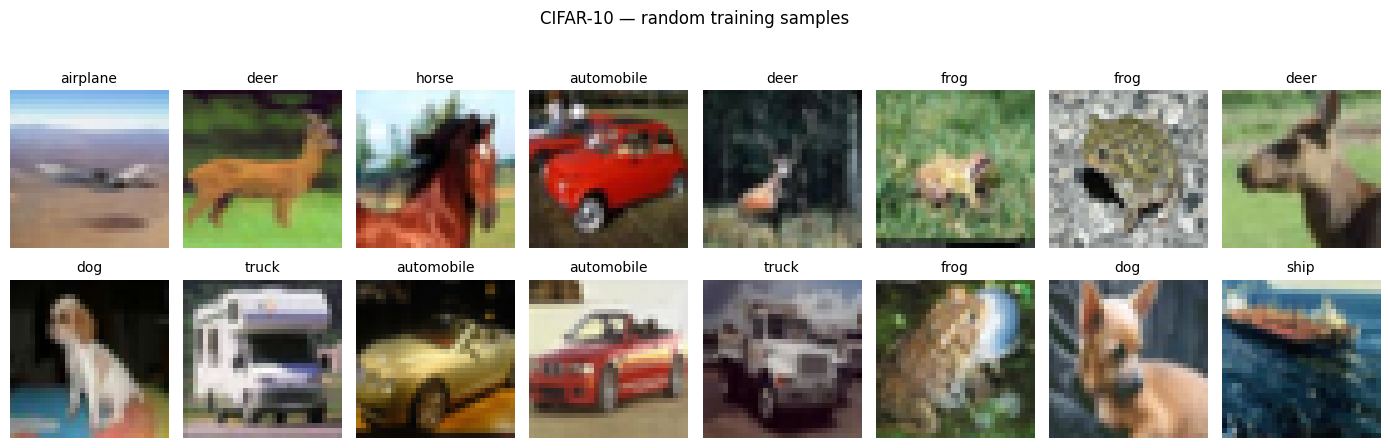

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4.5))
sample_idx = rng.choice(len(x_train_full_c), size=16, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_full_c[idx])
    ax.set_title(class_names_cifar[y_train_full_c[idx]], fontsize=10)
    ax.axis("off")
fig.suptitle("CIFAR-10 — random training samples", y=1.03)
plt.tight_layout()
plt.show()

### 3.3 Preprocess

In [ ]:
x_train_full_c_p = x_train_full_c.astype("float32") / 255.0
x_test_c_p = x_test_c.astype("float32") / 255.0

n_val_c = int(len(x_train_full_c_p) * 0.1)
x_val_c, y_val_c = x_train_full_c_p[:n_val_c], y_train_full_c[:n_val_c]
x_train_c, y_train_c = x_train_full_c_p[n_val_c:], y_train_full_c[n_val_c:]

print("Train:", x_train_c.shape, "Val:", x_val_c.shape, "Test:", x_test_c_p.shape)

Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


### 3.4 Build a (slightly deeper) simple CNN
CIFAR-10 is a harder task than MNIST, so this version adds a third conv block and light data augmentation.

In [ ]:
keras.backend.clear_session()

cifar_model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")],

        name="simple_cnn_cifar10")

cifar_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

cifar_model.summary()

Model: "simple_cnn_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

### 3.5 Train

Epoch 1/30
352/352 - 17s - 48ms/step - accuracy: 0.3047 - loss: 1.8886 - val_accuracy: 0.2972 - val_loss: 3.1843 - learning_rate: 0.0010
Epoch 2/30
352/352 - 8s - 23ms/step - accuracy: 0.4368 - loss: 1.5400 - val_accuracy: 0.5450 - val_loss: 1.3209 - learning_rate: 0.0010
Epoch 3/30
352/352 - 3s - 8ms/step - accuracy: 0.4988 - loss: 1.3918 - val_accuracy: 0.5930 - val_loss: 1.1925 - learning_rate: 0.0010
Epoch 4/30
352/352 - 3s - 8ms/step - accuracy: 0.5360 - loss: 1.2923 - val_accuracy: 0.5882 - val_loss: 1.1929 - learning_rate: 0.0010
Epoch 5/30
352/352 - 2s - 7ms/step - accuracy: 0.5643 - loss: 1.2301 - val_accuracy: 0.6302 - val_loss: 1.0358 - learning_rate: 0.0010
Epoch 6/30
352/352 - 2s - 7ms/step - accuracy: 0.5857 - loss: 1.1683 - val_accuracy: 0.6700 - val_loss: 0.9324 - learning_rate: 0.0010
Epoch 7/30
352/352 - 4s - 10ms/step - accuracy: 0.6061 - loss: 1.1150 - val_accuracy: 0.6214 - val_loss: 1.1298 - learning_rate: 0.0010
Epoch 8/30
352/352 - 6s - 18ms/step - accuracy: 0.6

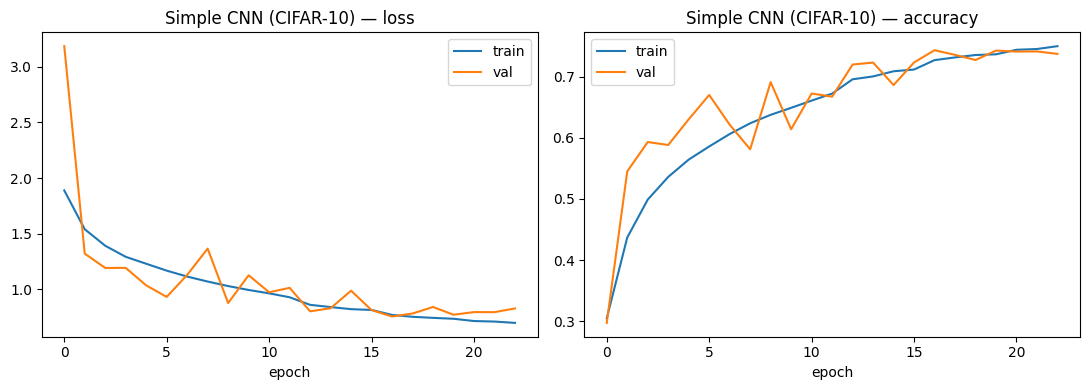

In [ ]:
callbacks_c = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

t0 = time.time()
history_c = cifar_model.fit(
    x_train_c, y_train_c,
    validation_data=(x_val_c, y_val_c),
    epochs=30, batch_size=128,
    callbacks=callbacks_c,
    verbose=2,
)
cifar_model_train_time = time.time() - t0
print(f"Training time: {cifar_model_train_time:.1f}s")

plot_history(history_c, "Simple CNN (CIFAR-10)")

### 3.6 Evaluate

Test accuracy: 0.7380
              precision    recall  f1-score   support

    airplane       0.80      0.69      0.74      1000
  automobile       0.90      0.81      0.85      1000
        bird       0.66      0.60      0.63      1000
         cat       0.59      0.50      0.54      1000
        deer       0.67      0.74      0.71      1000
         dog       0.63      0.66      0.65      1000
        frog       0.78      0.83      0.80      1000
       horse       0.82      0.78      0.80      1000
        ship       0.78      0.88      0.83      1000
       truck       0.75      0.89      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



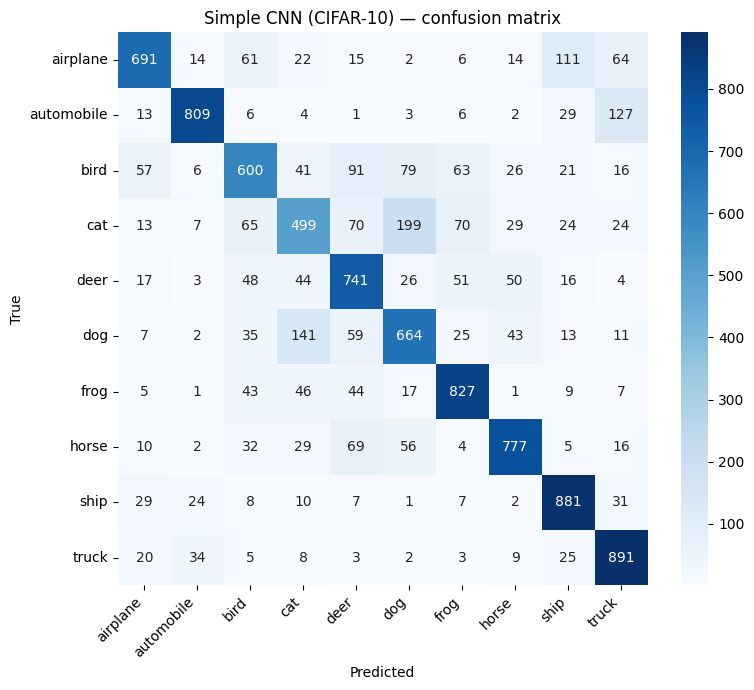

In [ ]:
test_loss_c, test_acc_c = cifar_model.evaluate(x_test_c_p, y_test_c, verbose=0)
print(f"Test accuracy: {test_acc_c:.4f}")

y_pred_c = np.argmax(cifar_model.predict(x_test_c_p, verbose=0), axis=1)
print(classification_report(y_test_c, y_pred_c, target_names=class_names_cifar))

cm_c = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_cifar, yticklabels=class_names_cifar)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Simple CNN (CIFAR-10) — confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

results["CIFAR-10 - Simple CNN"] = {
    "test_acc": test_acc_c,
    "params": cifar_model.count_params(),
    "train_time_s": cifar_model_train_time,
}

### 3.7 Visualize predictions

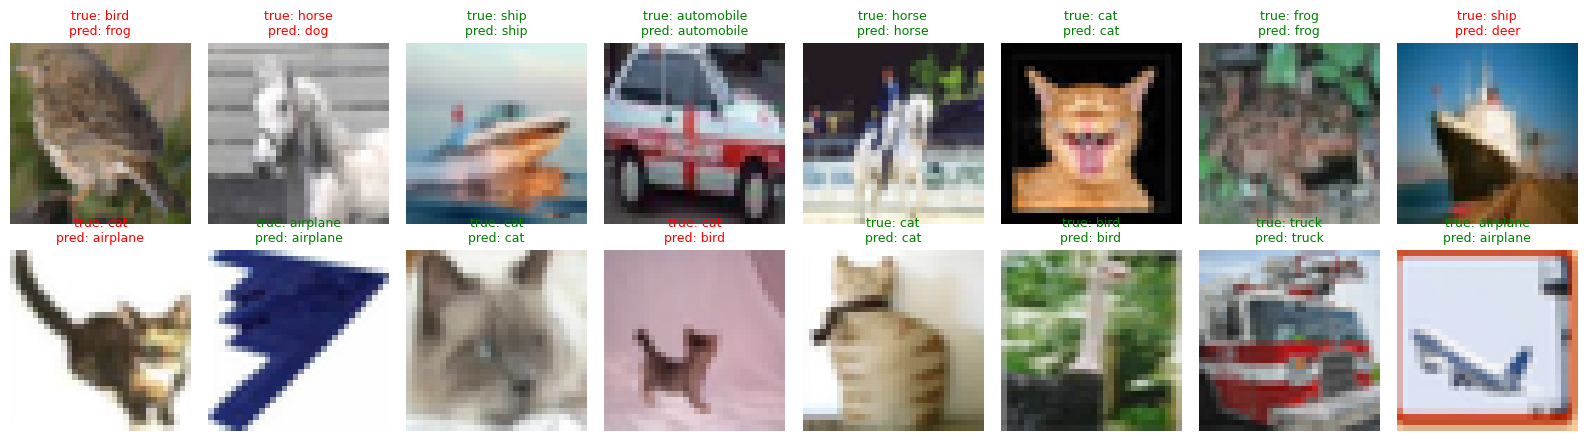

In [ ]:
show_predictions(x_test_c_p, y_test_c, y_pred_c, class_names_cifar)

### 3.8 VGG16 transfer learning on CIFAR-10

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

def make_vgg16_pipeline_cifar(images_uint8, batch_size=256):
    ds = tf.data.Dataset.from_tensor_slices(images_uint8)
    ds = ds.map(lambda img: vgg_preprocess(tf.cast(img, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

vgg16_base_c = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3), pooling="avg")
vgg16_base_c.trainable = False

t0 = time.time()
feat_train_c = extract_features(x_train_full_c[n_val_c:], vgg16_base_c, make_vgg16_pipeline_cifar)
feat_val_c = extract_features(x_train_full_c[:n_val_c], vgg16_base_c, make_vgg16_pipeline_cifar)
feat_test_c = extract_features(x_test_c, vgg16_base_c, make_vgg16_pipeline_cifar)
vgg16_cifar_feature_time = time.time() - t0
print("Feature shape:", feat_train_c.shape, f"(extracted in {vgg16_cifar_feature_time:.1f}s)")

176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step
Feature shape: (45000, 512) (extracted in 21.3s)


Epoch 1/20
352/352 - 4s - 12ms/step - accuracy: 0.4294 - loss: 3.3968 - val_accuracy: 0.5642 - val_loss: 1.2867
Epoch 2/20
352/352 - 1s - 3ms/step - accuracy: 0.5295 - loss: 1.3959 - val_accuracy: 0.6048 - val_loss: 1.1574
Epoch 3/20
352/352 - 1s - 3ms/step - accuracy: 0.5743 - loss: 1.2246 - val_accuracy: 0.6316 - val_loss: 1.0839
Epoch 4/20
352/352 - 1s - 3ms/step - accuracy: 0.6057 - loss: 1.1332 - val_accuracy: 0.6378 - val_loss: 1.0548
Epoch 5/20
352/352 - 1s - 3ms/step - accuracy: 0.6245 - loss: 1.0685 - val_accuracy: 0.6520 - val_loss: 1.0376
Epoch 6/20
352/352 - 1s - 3ms/step - accuracy: 0.6394 - loss: 1.0285 - val_accuracy: 0.6494 - val_loss: 1.0267
Epoch 7/20
352/352 - 2s - 5ms/step - accuracy: 0.6523 - loss: 0.9874 - val_accuracy: 0.6580 - val_loss: 1.0190
Epoch 8/20
352/352 - 2s - 6ms/step - accuracy: 0.6592 - loss: 0.9609 - val_accuracy: 0.6606 - val_loss: 1.0231
Epoch 9/20
352/352 - 1s - 3ms/step - accuracy: 0.6689 - loss: 0.9328 - val_accuracy: 0.6644 - val_loss: 1.0124


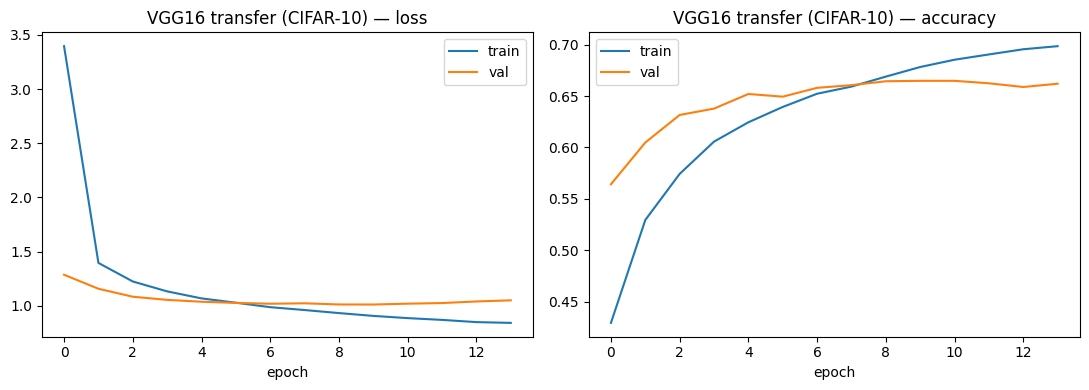

In [ ]:
cifar_vgg16_head = build_head(feat_train_c.shape[1], name="vgg16_head_cifar10")

t0 = time.time()
history_vgg16_c = cifar_vgg16_head.fit(
    feat_train_c, y_train_c,
    validation_data=(feat_val_c, y_val_c),
    epochs=20, batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=2,
)
cifar_vgg16_train_time = time.time() - t0 + vgg16_cifar_feature_time
plot_history(history_vgg16_c, "VGG16 transfer (CIFAR-10)")

Test accuracy: 0.6580
              precision    recall  f1-score   support

    airplane       0.71      0.71      0.71      1000
  automobile       0.73      0.75      0.74      1000
        bird       0.57      0.56      0.57      1000
         cat       0.47      0.50      0.48      1000
        deer       0.62      0.56      0.59      1000
         dog       0.60      0.58      0.59      1000
        frog       0.69      0.74      0.71      1000
       horse       0.72      0.68      0.70      1000
        ship       0.76      0.79      0.78      1000
       truck       0.71      0.70      0.71      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



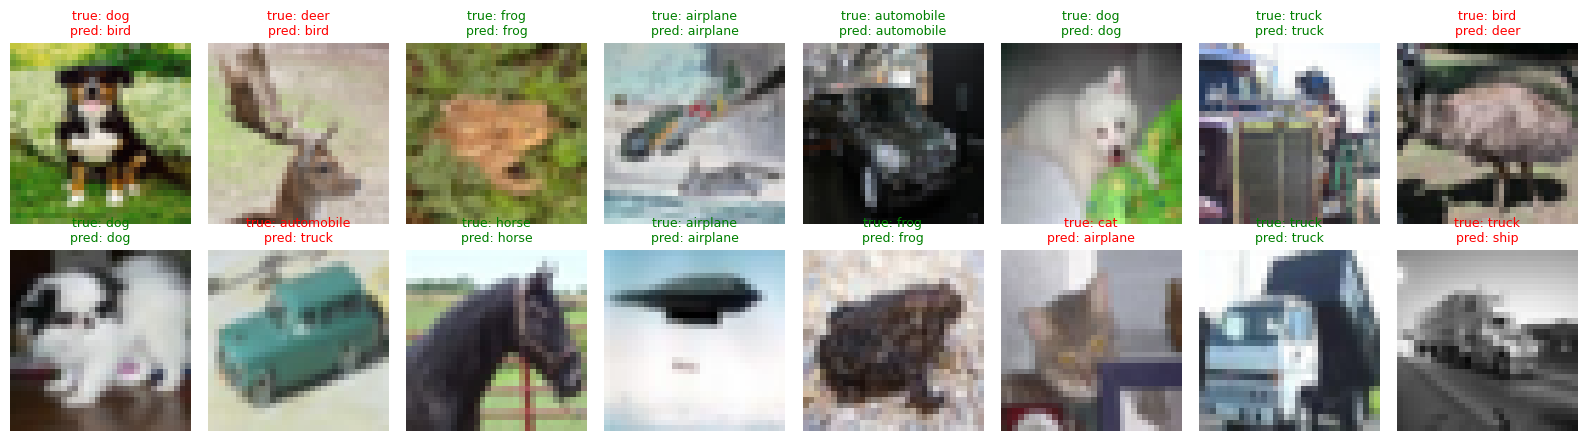

In [ ]:
test_loss_vc, test_acc_vc = cifar_vgg16_head.evaluate(feat_test_c, y_test_c, verbose=0)
print(f"Test accuracy: {test_acc_vc:.4f}")

y_pred_vgg16_c = np.argmax(cifar_vgg16_head.predict(feat_test_c, verbose=0), axis=1)
print(classification_report(y_test_c, y_pred_vgg16_c, target_names=class_names_cifar))

show_predictions(x_test_c_p, y_test_c, y_pred_vgg16_c, class_names_cifar)

results["CIFAR-10 - VGG16 transfer"] = {
    "test_acc": test_acc_vc,
    "params": cifar_vgg16_head.count_params() + vgg16_base_c.count_params(),
    "train_time_s": cifar_vgg16_train_time,
}

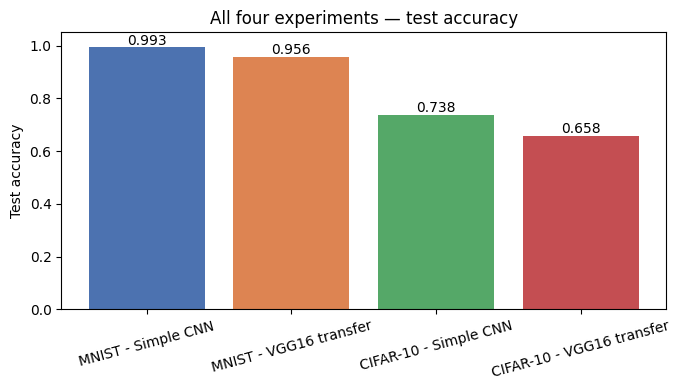

,test_acc,params,train_time_s
MNIST - Simple CNN,0.9932,422026,53.622336
MNIST - VGG16 transfer,0.9563,14848586,48.556089
CIFAR-10 - Simple CNN,0.7380,545482,88.820958
CIFAR-10 - VGG16 transfer,0.6580,14848586,40.619600


In [ ]:
plot_comparison(list(results.keys()), "All four experiments — test accuracy")

summary_df = pd.DataFrame(results).T
summary_df["params"] = summary_df["params"].astype(int)
summary_df

---
## Part 4 — YOLO: detection and instance segmentation

The slides cover YOLO as the flagship **one-stage detector** ("detection as regression") and trace the road to real-time **instance segmentation**.

**A quick note on the library switch.** Keras/TensorFlow don't ship a maintained, COCO-pretrained YOLO implementation, so this section uses [`ultralytics`](https://docs.ultralytics.com/) — the reference YOLOv8 implementation (PyTorch-based under the hood, but the whole workflow below is a handful of lines). Everything from Parts 1–3 stays pure Keras; this is the one deliberate exception, needed to get an actual pretrained detector + segmenter with almost no code.


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2

detector = YOLO("yolov8n.pt")       # object detection, COCO-pretrained (80 classes incl. 'person' and 'car')
segmenter = YOLO("yolov8n-seg.pt")  # instance segmentation, same model family

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


### 4.1 Sample images

Two canonical Ultralytics demo images (both contain people; one also contains a bus) plus a couple of images with **cars**, pulled from **COCO128** — a small official sample of the COCO dataset. Rather than hand-picking a "car" URL, we let the detector itself tell us which downloaded images contain one.


In [ ]:
sample_urls = [
    "https://ultralytics.com/images/bus.jpg",     # bus + several people
    "https://ultralytics.com/images/zidane.jpg",  # two people
]

from ultralytics.utils.downloads import download

coco128_dir = Path("datasets/coco128")
if not coco128_dir.exists():
    download(["https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip"], dir="datasets")

candidate_images = sorted((coco128_dir / "images" / "train2017").glob("*.jpg"))

car_image_paths = []
for img_path in candidate_images:
    r = detector.predict(str(img_path), verbose=False)[0]
    detected_classes = {r.names[int(c)] for c in r.boxes.cls}
    if "car" in detected_classes:
        car_image_paths.append(str(img_path))
    if len(car_image_paths) == 2:
        break

print(f"Found {len(car_image_paths)} COCO128 image(s) containing a car:")
for p in car_image_paths:
    print(" -", p)

sample_paths = sample_urls + car_image_paths

Unzipping datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.4Kfiles/s 0.1s
Found 2 COCO128 image(s) containing a car:
 - datasets/coco128/images/train2017/000000000064.jpg
 - datasets/coco128/images/train2017/000000000071.jpg


### 4.2 Object detection

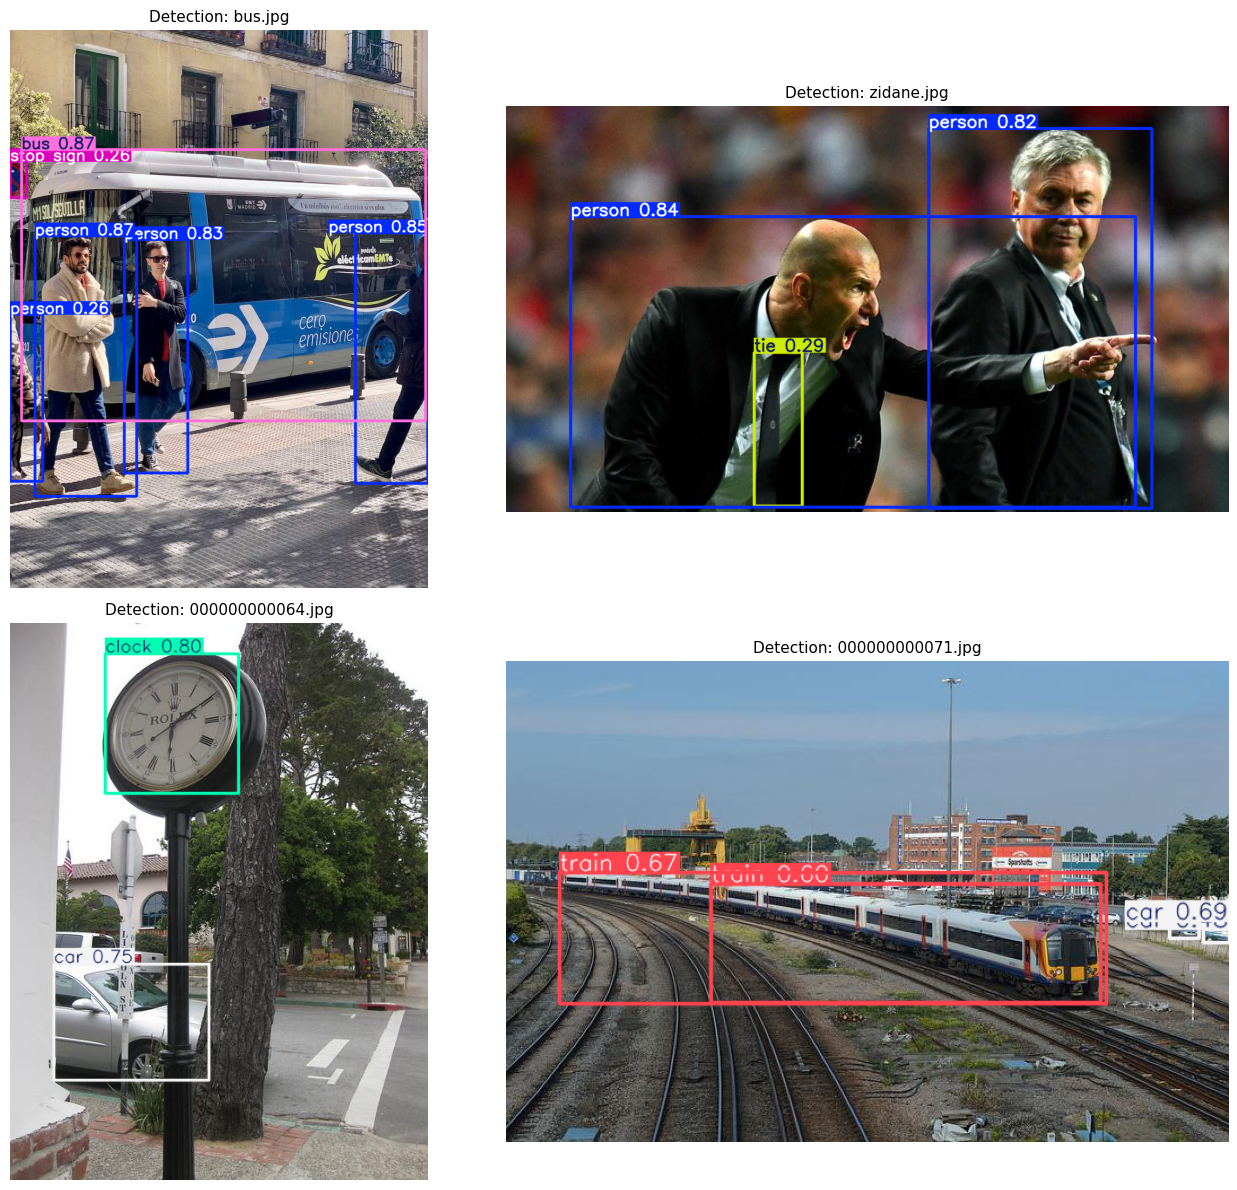

bus.jpg -> {'bus': 1, 'person': 4, 'stop sign': 1}
zidane.jpg -> {'person': 2, 'tie': 1}
000000000064.jpg -> {'clock': 1, 'car': 1}
000000000071.jpg -> {'car': 2, 'train': 2}


In [ ]:
def short_name(p):
    return p.split("/")[-1]

def show_yolo_results(results_list, titles, ncols=2):
    n = len(results_list)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, r, title in zip(axes, results_list, titles):
        annotated = r.plot()  # BGR numpy array with boxes/masks drawn
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

detection_results = [detector.predict(p, verbose=False)[0] for p in sample_paths]
show_yolo_results(detection_results, [f"Detection: {short_name(p)}" for p in sample_paths])

for p, r in zip(sample_paths, detection_results):
    counts = {}
    for c in r.boxes.cls:
        name = r.names[int(c)]
        counts[name] = counts.get(name, 0) + 1
    print(short_name(p), "->", counts)

### 4.3 Instance segmentation

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg


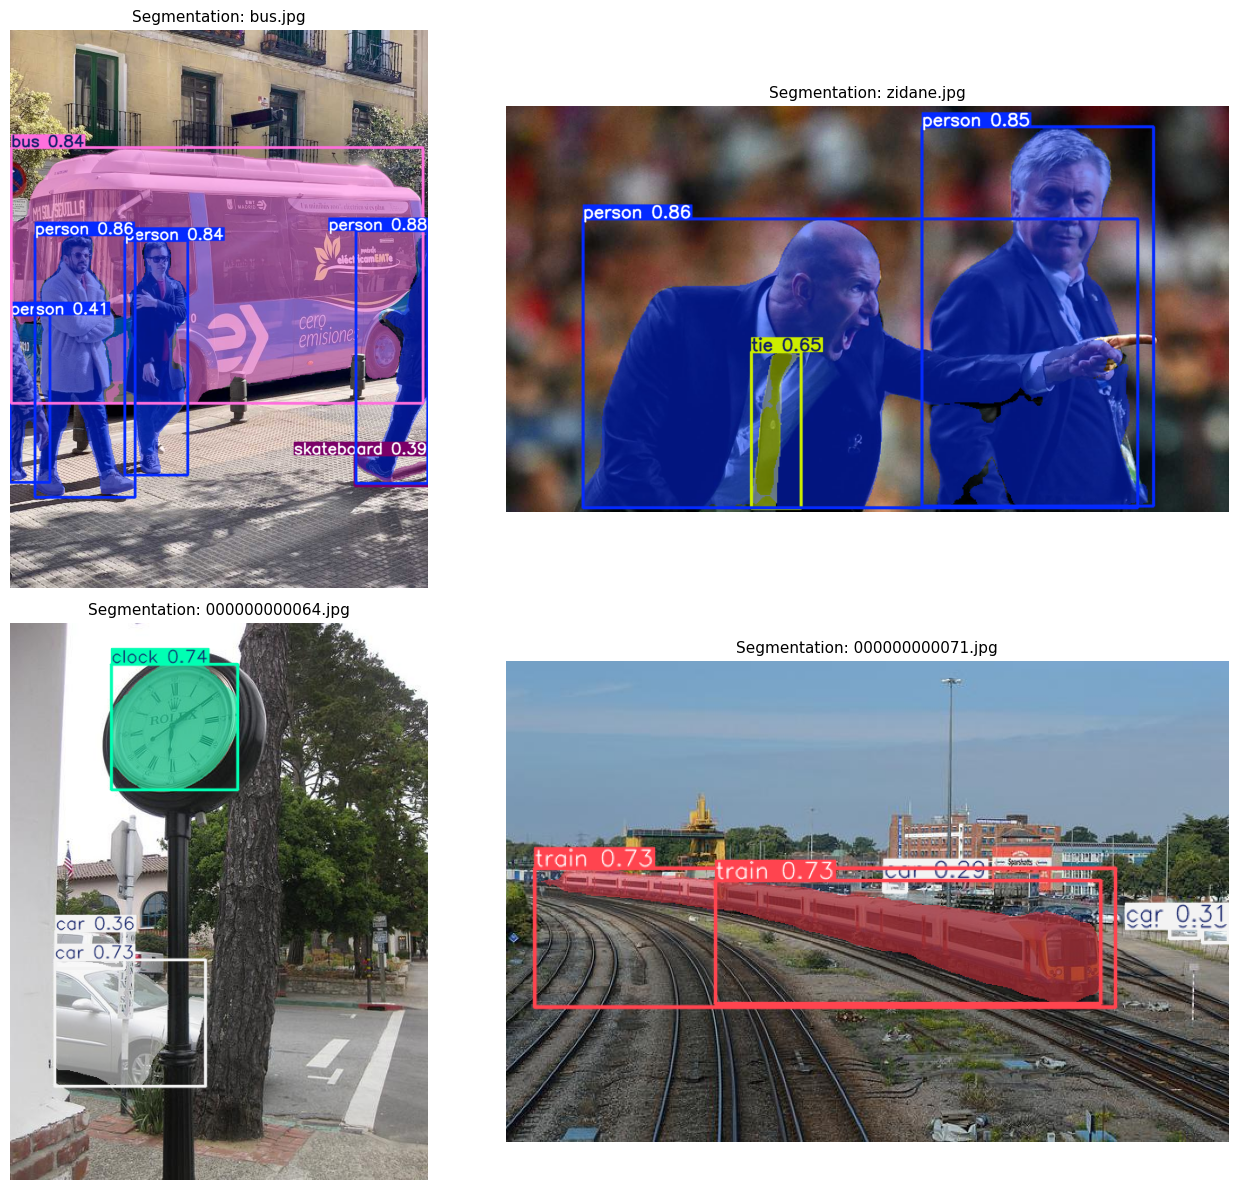

In [ ]:
segmentation_results = [segmenter.predict(p, verbose=False)[0] for p in sample_paths]
show_yolo_results(segmentation_results, [f"Segmentation: {short_name(p)}" for p in sample_paths])

Notice the segmentation model draws a full pixel **mask** per object, not just a box — and it does it in one forward pass, no separate region-proposal stage. That's conceptually close to the real-time instance segmentation idea from the slides (YOLACT/SOLO): attach a light mask branch to a fast one-stage detector, instead of the two-stage `Faster R-CNN + RoIAlign + mask head` pipeline used by Mask R-CNN.


---
## Wrap-up

### What we built
| # | Task | Model | Dataset |
|---|---|---|---|
| 1 | Classification | Simple CNN (from scratch) | MNIST |
| 2 | Classification | VGG16 (ImageNet, frozen base + trained head) | MNIST |
| 3 | Classification | Simple CNN (from scratch, deeper) | CIFAR-10 |
| 4 | Classification | VGG16 (ImageNet, frozen base + trained head) | CIFAR-10 |
| 5 | Detection + instance segmentation | YOLOv8n / YOLOv8n-seg (COCO-pretrained) | Sample images (people, cars) |

Run the cell below any time after Part 3 to see the final numbers together.


In [ ]:
summary_df

### Key takeaways (echoing the session)

1. **Convolution is a constrained matrix multiply** — sparse interactions, shared parameters, translation equivariance.
2. **Shape arithmetic is the everyday skill**: `(N + 2P − K) / S + 1` for feature-map size, `(K × K × D + 1) × K_out` for parameter count.
3. **Depth needs help to stay trainable** — small filters, 1×1 bottlenecks, residual connections, batch norm.
4. **Transfer learning pays off when domains match.** VGG16 barely helped on MNIST but should show a real gain on CIFAR-10 — same backbone, different amount of shared visual structure with ImageNet.
5. **Beyond classification, only the output head changes.** Detection and segmentation reuse the same convolutional backbone idea; YOLO's whole pitch is doing that head as a single, real-time regression pass.

### Where to go next
- Unfreeze the top VGG16 block and fine-tune end-to-end with a low learning rate (`1e-5`) on CIFAR-10.
- Swap `VGG16` for `ResNet50` or `EfficientNetB0` from `keras.applications` and compare.
- Fine-tune `yolov8n.pt` on a small custom dataset (`model.train(data="your_data.yaml", epochs=50)`).
- Try [Segment Anything (SAM)](https://docs.ultralytics.com/models/sam/) for promptable, zero-shot segmentation — the model referenced at the end of the segmentation slides.
